In [2]:
import bioframe as bf
import pandas as pd
import numpy as np
import bbi
import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [ ]:
bigWig_control = bbi.open(
    'mergedReplicate/bigwig/control.mRp.clN.bigWig')
bigWig_exp = bbi.open(
    'mergedReplicate/bigwig/experimental.mRp.clN.bigWig')

In [4]:
# Get chromosome sizes
chrom_sizes = bigWig_exp.chromsizes

# Define the bin size (2000 nucleotides)
bin_size = 2000

# Create an empty list to store bin coordinates
bin_coordinates = []

# Iterate over each chromosome
for chrom, chrom_size in chrom_sizes.items():
    # Generate bin coordinates for the current chromosome
    for start in range(0, chrom_size, bin_size):
        end = min(start + bin_size, chrom_size)
        bin_coordinates.append((chrom, start, end))

bin_array = np.array(bin_coordinates)

df = pd.DataFrame(bin_array, columns=['chrom', 'start', 'end'])
df = df.astype({'chrom':'string', 'start':'int', 'end':'int'})


In [ ]:
# Load genome annotation to extract TSS coordinates (promoters)

annot_gtf = pd.read_csv('Mus_musculus_GTF_genes_short_GRCm38_95.csv')

annot_gtf_tss = annot_gtf.copy()

annot_gtf_tss['start'] = annot_gtf.apply(lambda row: row['start'] if row['strand'] == '+' else row['end'], axis=1)

annot_gtf_tss['end'] = annot_gtf_tss['start']+1

In [10]:
annot_gtf_tss['chrom'] = annot_gtf_tss['chrom'].str.replace('chr', '')

In [11]:
annot_gtf_tss = annot_gtf_tss[annot_gtf_tss['chrom'] != 'MT']

In [12]:
annot_gtf_tss.sort_values(by=['chrom', 'start'])
annot_gtf_tss = annot_gtf_tss[['chrom', 'start', 'end']]

In [13]:
df_noTSS = bf.setdiff(df, annot_gtf_tss)

In [14]:
df_noTSS_noSex = df_noTSS[df_noTSS['chrom'].str.contains('Y|X') == False].copy()

In [15]:
df_noTSS_Sex = df_noTSS[df_noTSS['chrom'].str.contains('Y|X') == True].copy()

In [16]:
df_TSS = bf.coverage(df, annot_gtf_tss)
df_TSS = df_TSS[df_TSS.coverage != 0].copy()

In [17]:
print(len(df)) # all bins
print(len(df_TSS)) # bins on promoters
print(len(df_noTSS_Sex)) # bins on sex chromosomes outside promoters
print(len(df_noTSS_noSex)) # bins on autosomes outside promoters

1362770
50475
127342
1184953


In [23]:
print(len(df_TSS)/len(df))
print(len(df_noTSS_Sex)/len(df))
print(len(df_noTSS_noSex)/len(df))

0.03703853181387908
0.0934435011043683
0.8695179670817526


In [25]:
df0 = df_noTSS_noSex

cov_control_noSex_noTSS = bigWig_control_consensus.stackup(df0["chrom"],
                                                           df0["start"],
                                                           df0["end"],
                                                           bins=1, summary='sum').flatten()
cov_exp_noSex_noTSS = bigWig_exp_consensus.stackup(df0["chrom"],
                                                   df0["start"],
                                                   df0["end"],
                                                   bins=1, summary='sum').flatten()

In [26]:
np.savez_compressed(
    "coverages_noSex_noTSS.npz",
    cov_control_noSex_noTSS=cov_control_noSex_noTSS,
    cov_exp_noSex_noTSS=cov_exp_noSex_noTSS
)

In [27]:
df0 = df_noTSS_Sex

cov_control_Sex = bigWig_control_consensus.stackup(df0["chrom"],
                                                          df0["start"],
                                                          df0["end"],
                                                          bins=1, summary='sum').flatten()
cov_exp_Sex = bigWig_exp_consensus.stackup(df0["chrom"],
                                                   df0["start"],
                                                   df0["end"],
                                                   bins=1, summary='sum').flatten()

In [28]:
np.savez_compressed(
    "covarages_Sex.npz",
    cov_control_Sex=cov_control_Sex,
    cov_exp_Sex=cov_exp_Sex
)

In [29]:
df0 = df_TSS

cov_control_TSS = bigWig_control_consensus.stackup(df0["chrom"],
                                                          df0["start"],
                                                          df0["end"],
                                                          bins=1, summary='sum').flatten()
cov_exp_TSS = bigWig_exp_consensus.stackup(df0["chrom"],
                                                   df0["start"],
                                                   df0["end"],
                                                   bins=1, summary='sum').flatten()

In [30]:
np.savez_compressed(
    "covarages_TSS.npz",
    cov_control_TSS=cov_control_TSS,
    cov_exp_TSS=cov_exp_TSS
)

In [18]:
covs = np.load("coverages_noSex_noTSS.npz")
cov_control_noSex_noTSS = covs["cov_control_noSex_noTSS"]
cov_exp_noSex_noTSS = covs["cov_exp_noSex_noTSS"]

In [19]:
covs1 = np.load("covarages_Sex.npz")
cov_control_Sex = covs1["cov_control_Sex"]
cov_exp_Sex = covs1["cov_exp_Sex"]

In [20]:
covs2 = np.load("covarages_TSS.npz")
cov_control_TSS = covs2["cov_control_TSS"]
cov_exp_TSS = covs2["cov_exp_TSS"]

In [24]:
mask1 = (cov_control_noSex_noTSS>0) & (cov_exp_noSex_noTSS>0)
xs_1 = np.log10(cov_control_noSex_noTSS[mask1])
ys_1 = np.log10(cov_exp_noSex_noTSS[mask1])

mask2 = (cov_control_Sex>0) & (cov_exp_Sex>0)
xs_2 = np.log10(cov_control_Sex[mask2])
ys_2 = np.log10(cov_exp_Sex[mask2])

mask3 = (cov_control_TSS>0) & (cov_exp_TSS>0)
xs_3 = np.log10(cov_control_TSS[mask3])
ys_3 = np.log10(cov_exp_TSS[mask3])

In [26]:
cs_1 = np.full(len(xs_1), '#a5a5a5') #all grey
cs_2 = np.full(len(xs_2), '#5BA300') #Sex green
cs_3 = np.full(len(xs_3), '#5928ed') #TSS purple

In [28]:
xs = np.concatenate([xs_1, xs_2, xs_3])
ys = np.concatenate([ys_1, ys_2, ys_3])
cs = np.concatenate([cs_1, cs_2, cs_3])

In [29]:
order = np.arange(0, xs.shape[0])
np.random.shuffle(order)

In [30]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # TrueType
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.size'] = 16 


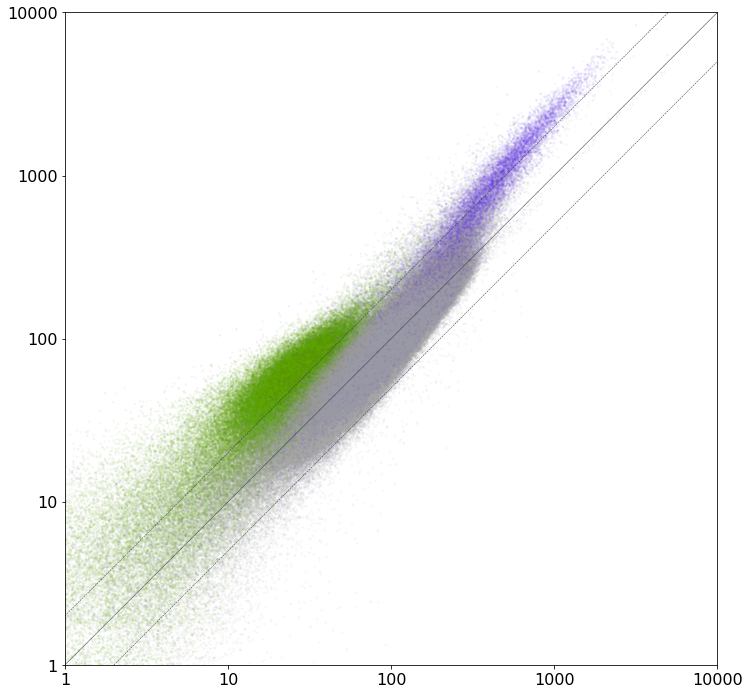

In [33]:
# Chromatin accessibilily CONTROL / CHD1cKO, whole genome in 2kb bins

fig = plt.figure(figsize=[12,12])                            
ax = plt.gca()
ax.set_rasterization_zorder(0)                               

plt.scatter(
    xs[order], ys[order],
    c=cs[order],
    s=6,
    alpha=0.08,
    edgecolors='none',
    linewidths=0,
    zorder=-1,                                              
    rasterized=False                                          
)

plt.gca().set(
    aspect=1.0,
    xlim=[0, 4],
    ylim=[0, 4]
)

#plt.xlabel('Chromatin accesibility in 2kb genomic bins, CONTROL', fontsize=16)
#plt.ylabel('Chromatin accesibility in 2kb genomic bins, CHD1 KO', fontsize=16)

plt.tick_params(labelsize=16)

def custom_tick_formatter(x, pos):
    return f'{int(10**x)}'  # Round and convert to integer

# Custom tick locator
def custom_tick_locator():
    locs = np.arange(0, 4.1, 1)  # Adjust these values based on your data
    return plt.FixedLocator(locs)

# Set x-axis tick labels to non-log-transformed values
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(custom_tick_formatter))
plt.gca().xaxis.set_major_locator(custom_tick_locator())

# Set y-axis tick labels to non-log-transformed values
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(custom_tick_formatter))
plt.gca().yaxis.set_major_locator(custom_tick_locator())

# Add diagonal lines
x_line = np.linspace(0, 4, 100)
y_line_plus = x_line + np.log10(2) #log10(2) = 0.301, log10(1.5) = 0.176
y_line_minus = x_line - np.log10(2)
y_line_equals_x = x_line

plt.plot(x_line, y_line_plus, color='#303943', linestyle='dashed', linewidth=0.5)
plt.plot(x_line, y_line_equals_x, color='#303943', linestyle='solid', linewidth=0.5)
plt.plot(x_line, y_line_minus, color='#303943', linestyle='dashed', linewidth=0.5)

# plt.savefig(
#     "Chromatin_accessibility_in_geomic_bins_c4.pdf",
#     dpi=600,                                                 
#     bbox_inches="tight",
#     pad_inches=1,
#     transparent=False                                       
# )

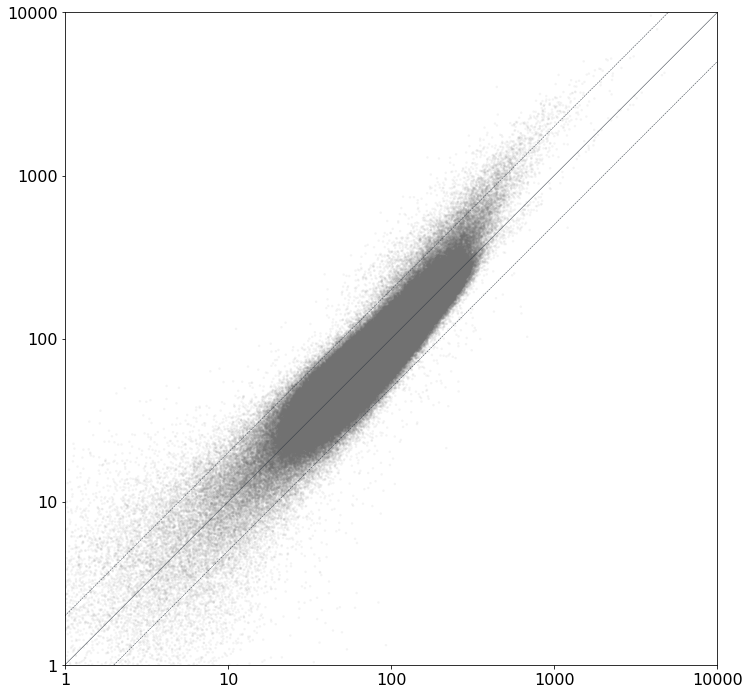

In [33]:
# Chromatin accessibilily CONTROL / CHD1cKO, whole genome in 2kb bins (bins overlapping TSSs are excluded, bins from sex chromoaomes are excluded)

fig = plt.figure(figsize=[12,12])                            
ax = plt.gca()
ax.set_rasterization_zorder(0)                               

plt.scatter(
    xs_1, ys_1,
    c='#717171',
    s=6,
    alpha=0.08,
    edgecolors='none',
    linewidths=0,
    zorder=-1,                                              
    rasterized=False                                          
)

plt.gca().set(
    aspect=1.0,
    xlim=[0, 4],
    ylim=[0, 4]
)

#plt.xlabel('Chromatin accesibility in 2kb genomic bins, CONTROL', fontsize=16)
#plt.ylabel('Chromatin accesibility in 2kb genomic bins, CHD1 KO', fontsize=16)

plt.tick_params(labelsize=16)

def custom_tick_formatter(x, pos):
    return f'{int(10**x)}'  # Round and convert to integer

# Custom tick locator
def custom_tick_locator():
    locs = np.arange(0, 4.1, 1)  # Adjust these values based on your data
    return plt.FixedLocator(locs)

# Set x-axis tick labels to non-log-transformed values
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(custom_tick_formatter))
plt.gca().xaxis.set_major_locator(custom_tick_locator())

# Set y-axis tick labels to non-log-transformed values
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(custom_tick_formatter))
plt.gca().yaxis.set_major_locator(custom_tick_locator())

# Add diagonal lines
x_line = np.linspace(0, 4, 100)
y_line_plus = x_line + np.log10(2) #log10(2) = 0.301, log10(1.5) = 0.176
y_line_minus = x_line - np.log10(2)
y_line_equals_x = x_line

plt.plot(x_line, y_line_plus, color='#303943', linestyle='dashed', linewidth=0.5)
plt.plot(x_line, y_line_equals_x, color='#303943', linestyle='solid', linewidth=0.5)
plt.plot(x_line, y_line_minus, color='#303943', linestyle='dashed', linewidth=0.5)

# plt.savefig(
#     "Chromatin_accessibility_in_geomic_bins_Automomes_noSex_dGray.pdf",
#     dpi=600,                                                 
#     bbox_inches="tight",
#     pad_inches=1,
#     transparent=False                                       
# )

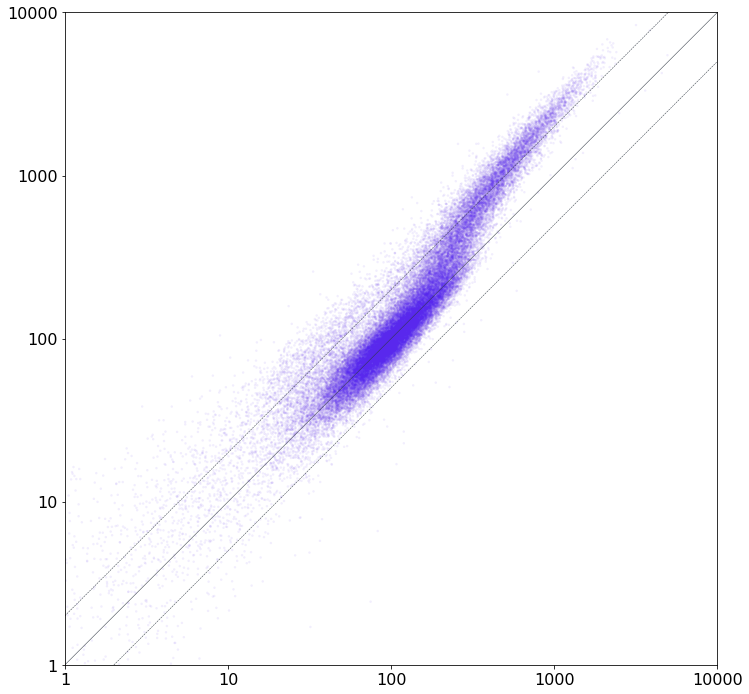

In [28]:
# Chromatin accessibilily CONTROL / CHD1cKO, only 2kb bins overlapping TSSs 

fig = plt.figure(figsize=[12,12])                            
ax = plt.gca()
ax.set_rasterization_zorder(0)                               

plt.scatter(
    xs_3, ys_3,
    c=cs_3,
    s=6,
    alpha=0.08,
    edgecolors='none',
    linewidths=0,
    zorder=-1,                                              
    rasterized=False                                          
)

plt.gca().set(
    aspect=1.0,
    xlim=[0, 4],
    ylim=[0, 4]
)

#plt.xlabel('Chromatin accesibility in 2kb genomic bins, CONTROL', fontsize=16)
#plt.ylabel('Chromatin accesibility in 2kb genomic bins, CHD1 KO', fontsize=16)

plt.tick_params(labelsize=16)

def custom_tick_formatter(x, pos):
    return f'{int(10**x)}'  # Round and convert to integer

# Custom tick locator
def custom_tick_locator():
    locs = np.arange(0, 4.1, 1)  # Adjust these values based on your data
    return plt.FixedLocator(locs)

# Set x-axis tick labels to non-log-transformed values
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(custom_tick_formatter))
plt.gca().xaxis.set_major_locator(custom_tick_locator())

# Set y-axis tick labels to non-log-transformed values
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(custom_tick_formatter))
plt.gca().yaxis.set_major_locator(custom_tick_locator())

# Add diagonal lines
x_line = np.linspace(0, 4, 100)
y_line_plus = x_line + np.log10(2) #log10(2) = 0.301, log10(1.5) = 0.176
y_line_minus = x_line - np.log10(2)
y_line_equals_x = x_line

plt.plot(x_line, y_line_plus, color='#303943', linestyle='dashed', linewidth=0.5)
plt.plot(x_line, y_line_equals_x, color='#303943', linestyle='solid', linewidth=0.5)
plt.plot(x_line, y_line_minus, color='#303943', linestyle='dashed', linewidth=0.5)

# plt.savefig(
#     "Chromatin_accessibility_in_geomic_bins_over_promoters_c3.pdf",
#     dpi=600,                                                 
#     bbox_inches="tight",
#     pad_inches=1,
#     transparent=False                                       
# )

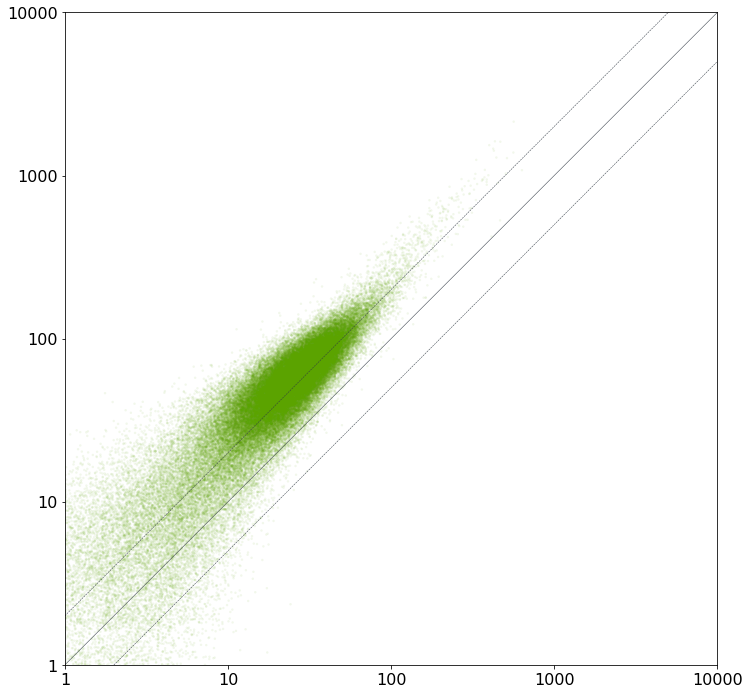

In [37]:
# Chromatin accessibilily CONTROL / CHD1cKO, only sex chromosomes in 2kb bins (bins overlapping promoters are excluded)

fig = plt.figure(figsize=[12,12])                            
ax = plt.gca()
ax.set_rasterization_zorder(0)                               

plt.scatter(
    xs_2, ys_2,
    c=cs_2,
    s=6,
    alpha=0.08,
    edgecolors='none',
    linewidths=0,
    zorder=-1,                                              
    rasterized=False                                          
)

plt.gca().set(
    aspect=1.0,
    xlim=[0, 4],
    ylim=[0, 4]
)

#plt.xlabel('Chromatin accesibility in 2kb genomic bins, CONTROL', fontsize=16)
#plt.ylabel('Chromatin accesibility in 2kb genomic bins, CHD1 KO', fontsize=16)

plt.tick_params(labelsize=16)

def custom_tick_formatter(x, pos):
    return f'{int(10**x)}'  # Round and convert to integer

# Custom tick locator
def custom_tick_locator():
    locs = np.arange(0, 4.1, 1)  # Adjust these values based on your data
    return plt.FixedLocator(locs)

# Set x-axis tick labels to non-log-transformed values
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(custom_tick_formatter))
plt.gca().xaxis.set_major_locator(custom_tick_locator())

# Set y-axis tick labels to non-log-transformed values
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(custom_tick_formatter))
plt.gca().yaxis.set_major_locator(custom_tick_locator())

# Add diagonal lines
x_line = np.linspace(0, 4, 100)
y_line_plus = x_line + np.log10(2) #log10(2) = 0.301, log10(1.5) = 0.176
y_line_minus = x_line - np.log10(2)
y_line_equals_x = x_line

plt.plot(x_line, y_line_plus, color='#303943', linestyle='dashed', linewidth=0.5)
plt.plot(x_line, y_line_equals_x, color='#303943', linestyle='solid', linewidth=0.5)
plt.plot(x_line, y_line_minus, color='#303943', linestyle='dashed', linewidth=0.5)


# plt.savefig(
#     "Chromatin_accessibility_in_geomic_bins_over_Sexchromosomes.pdf",
#     dpi=600,                                                 
#     bbox_inches="tight",
#     pad_inches=1,
#     transparent=False                                       
# )